# Try Yahoo Finance

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf 

Get some data on exchange rates from Yahoo Finance.

In [2]:
tickers = yf.Ticker("EURCHF=X CHFEUR=X")
exchange_rates = yf.download(["EURCHF=X", "CHFEUR=X"], start = "2026-01-01", interval = "1d")

[*********************100%***********************]  2 of 2 completed


In [3]:
print(exchange_rates.head())
type(exchange_rates)

Price          Close               High                Low               Open  \
Ticker      CHFEUR=X EURCHF=X  CHFEUR=X EURCHF=X  CHFEUR=X EURCHF=X  CHFEUR=X   
Date                                                                            
2026-01-02  1.074356  0.93061  1.077076  0.93155  1.073300  0.92831  1.074402   
2026-01-05  1.076716  0.92858  1.078586  0.93050  1.074560  0.92699  1.076844   
2026-01-06  1.077470  0.92792  1.077807  0.93015  1.074910  0.92764  1.077370   
2026-01-07  1.075050  0.92997  1.075940  0.93140  1.073490  0.92930  1.075165   
2026-01-08  1.073340  0.93140  1.074391  0.93190  1.072961  0.93060  1.073370   

Price                 Volume           
Ticker     EURCHF=X CHFEUR=X EURCHF=X  
Date                                   
2026-01-02  0.93057        0        0  
2026-01-05  0.92849        0        0  
2026-01-06  0.92798        0        0  
2026-01-07  0.92993        0        0  
2026-01-08  0.93136        0        0  


pandas.DataFrame

Try plotting

Ticker      CHFEUR=X  EURCHF=X
Date                          
2026-01-02  1.074356   0.93061
2026-01-05  1.076716   0.92858
2026-01-06  1.077470   0.92792
2026-01-07  1.075050   0.92997
2026-01-08  1.073340   0.93140
...              ...       ...
2026-09-21  1.058885   0.94424
2026-09-22  1.062462   0.94108
2026-09-23  1.064056   0.93956
2026-09-24  1.064668   0.93913
2026-09-25  1.058200   0.94450

[191 rows x 2 columns]


<Axes: xlabel='Date'>

<Figure size 640x480 with 0 Axes>

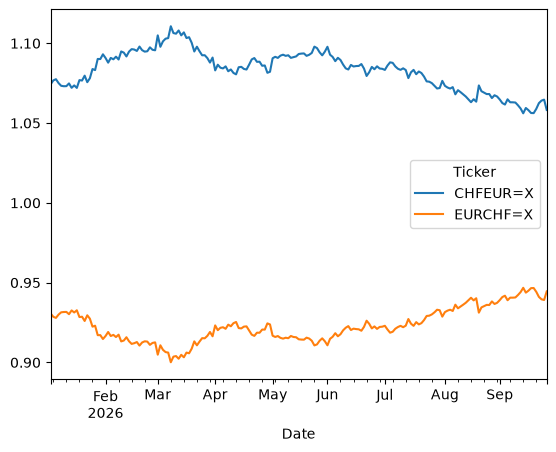

In [4]:
print(exchange_rates["Close"])
plt.figure()
exchange_rates["Close"].plot()

Try to calculate change in exchange rate per day.

In [5]:
exchange_rates["Intraday Difference", "CHFEUR=X"] = exchange_rates["Close", "CHFEUR=X"] - exchange_rates["Open", "CHFEUR=X"]
exchange_rates["Intraday Difference", "EURCHF=X"] = exchange_rates["Close", "EURCHF=X"] - exchange_rates["Open", "EURCHF=X"]

exchange_rates["Intraday Return", "CHFEUR=X"] = exchange_rates["Intraday Difference", "CHFEUR=X"] / exchange_rates["Open", "CHFEUR=X"]
exchange_rates["Intraday Return", "EURCHF=X"] = exchange_rates["Intraday Difference", "EURCHF=X"] / exchange_rates["Open", "EURCHF=X"]

In [6]:
exchange_rates[["Intraday Difference", "Intraday Return"]]

Price      Intraday Difference          Intraday Return          
Ticker                CHFEUR=X EURCHF=X        CHFEUR=X  EURCHF=X
Date                                                             
2026-01-02           -0.000046  0.00004       -0.000043  0.000043
2026-01-05           -0.000128  0.00009       -0.000119  0.000097
2026-01-06            0.000100 -0.00006        0.000093 -0.000065
2026-01-07           -0.000115  0.00004       -0.000107  0.000043
2026-01-08           -0.000030  0.00004       -0.000028  0.000043
...                        ...      ...             ...       ...
2026-09-21           -0.000078  0.00005       -0.000074  0.000053
2026-09-22            0.000113  0.00006        0.000106  0.000064
2026-09-23           -0.000045 -0.00007       -0.000042 -0.000074
2026-09-24           -0.000102  0.00007       -0.000096  0.000075
2026-09-25           -0.003000  0.00310       -0.002827  0.003293

[191 rows x 4 columns]

Try out currency conversion

In [14]:
print(exchange_rates["Close", "CHFEUR=X"].iloc[-1])
exchange_rates.index[-1]

1.0582000017166138


Timestamp('2026-09-25 00:00:00')

In [15]:
money_in_CHF = 5
money_in_EUR = money_in_CHF * exchange_rates["Close", "CHFEUR=X"].iloc[-1]
print(f"{money_in_CHF} CHF is {money_in_EUR} EUR on {exchange_rates.index[-1]}")

5 CHF is 5.291000008583069 EUR on 2026-09-25 00:00:00
